<a href="https://colab.research.google.com/github/Trixxzer/PrajwolShrestha_2418111_AIML_Worksheets/blob/main/Week7_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

In [ ]:
dataset_path = "/content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(dataset_path, "Train")
test_dir  = os.path.join(dataset_path, "Test")

<h1>Load and Preprocess Images</h1>

In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt



IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    images, labels = [], []

    class_names = sorted(os.listdir(folder))
    class_map = {name: idx for idx, name in enumerate(class_names)}
    print(f"Classes found in {folder}: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img, dtype=np.float32) / 255.0
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

print("Train dir:", train_dir)
print("Test dir :", test_dir)
print("Train exists:", os.path.exists(train_dir))
print("Test exists :", os.path.exists(test_dir))

print("\nLoading training data ...")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("\nLoading test data ...")
x_test_raw, y_test_raw = load_images_from_folder(test_dir)

print(f"\nRaw training set : {x_train_raw.shape}, labels: {y_train_raw.shape}")
print(f"Raw test set     : {x_test_raw.shape}, labels: {y_test_raw.shape}")

Train dir: /content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Train
Test dir : /content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Test
Train exists: True
Test exists : True

Loading training data ...
Classes found in /content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Train: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3}

Loading test data ...
Classes found in /content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Test: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Skipping /content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png: cannot identify image file '/content/drive/MyDrive/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png'

Raw training set : (5070, 28, 28), labels: (5070,)
Raw test set     : (2999, 28, 28), labels: (2999,)


<h1>Reshape Image data</h1>

In [13]:
x_train = x_train_raw.reshape(-1, 28, 28, 1)
x_test = x_test_raw.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (5070, 28, 28, 1)
Testing data shape: (2999, 28, 28, 1)


<h1>Add Noise</h1>

In [14]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy training data shape:", x_train_noisy.shape)
print("Noisy testing data shape:", x_test_noisy.shape)

Noisy training data shape: (5070, 28, 28, 1)
Noisy testing data shape: (2999, 28, 28, 1)


<h1>Visualize Data</h1>

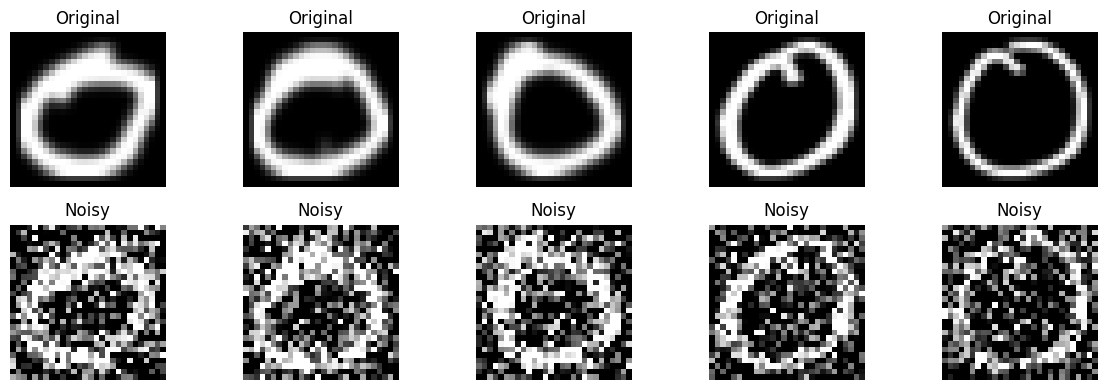

In [15]:
n = 5
plt.figure(figsize=(12, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

<h1>Build Denoising Autoencoder</h1>

In [16]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

<h1>Train Encoder</h1>

In [17]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 555ms/step - loss: 0.4734 - val_loss: 0.2909
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - loss: 0.2585 - val_loss: 0.2412
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 459ms/step - loss: 0.2279 - val_loss: 0.2237
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 473ms/step - loss: 0.2165 - val_loss: 0.2163
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 457ms/step - loss: 0.2098 - val_loss: 0.2096
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 465ms/step - loss: 0.2074 - val_loss: 0.2069
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 470ms/step - loss: 0.2031 - val_loss: 0.2040
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 459ms/step - loss: 0.2007 - val_loss: 0.2025
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 456ms/step - loss: 0.1986 - val_loss: 0.2013
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - loss: 0.1985 - val_loss: 0.2025


<h1>Plot Training and Validation Loss</h1>

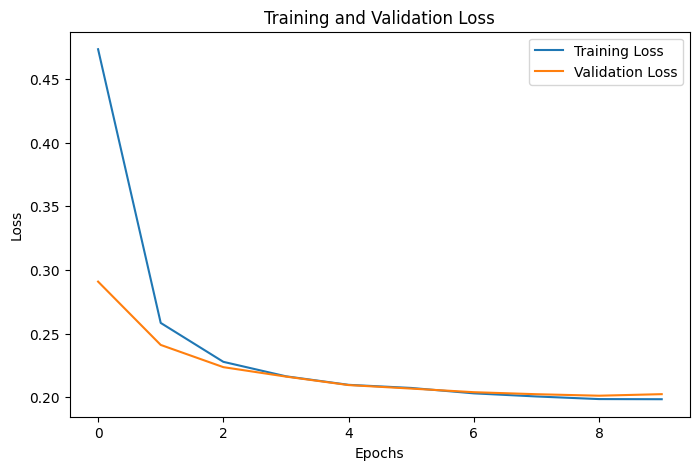

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h1>Predict Denoised Images</h1>

In [19]:
denoised_images = autoencoder.predict(x_test_noisy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


<h1>Final Output Visualization</h1>

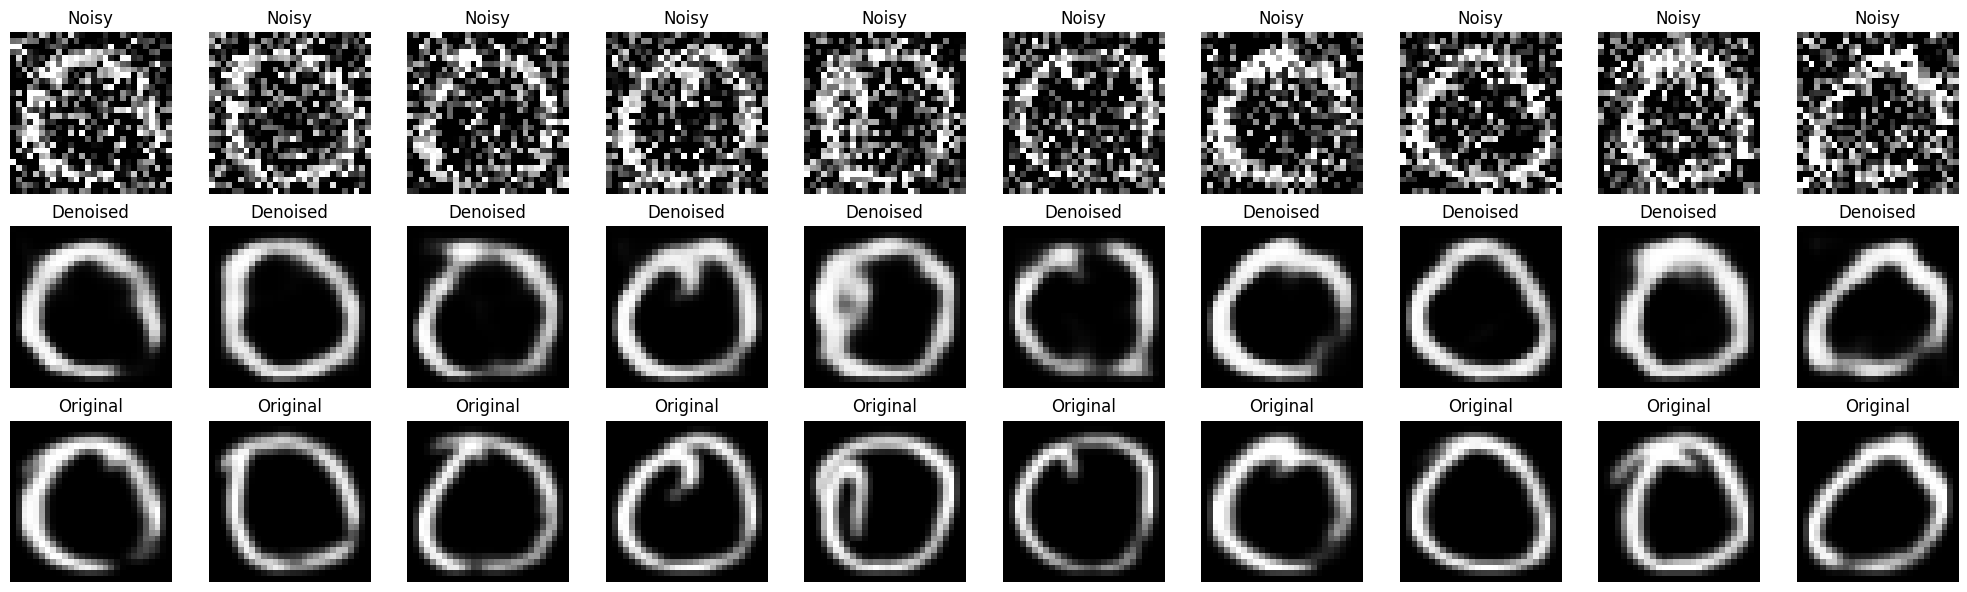

In [20]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()